# Semantic Segmentation & Instance Detection — Layer by Layer

**Computational Vision — companion notebook to Chapter 28**

This notebook implements, **from scratch in NumPy**, every layer discussed in the
Semantic Segmentation chapter, plus the RoI layers from the R-CNN / Mask R-CNN
chapter. The point is *not* to train a network — it is to see **the exact
arithmetic** each layer performs on small, hand-checkable inputs.

Wherever possible the numbers match the worked `Numeric example` boxes in your
notes, so you can verify code output against the LaTeX.

**Contents**
1. Setup & a tiny visualisation helper
2. Downsampling — max / average pooling
3. Downsampling — strided convolution
4. Upsampling — nearest-neighbour, bed-of-nails, **max unpooling** (with stored argmax)
5. Upsampling — **transposed convolution** (overlap-add), 1-D and 2-D
6. A full **encoder–decoder** (mini U-Net) forward pass on a real shape
7. The dense-prediction head: per-pixel `softmax` → `argmax` label map
8. **Semantic vs. instance** segmentation — the class-vs-instance difference, in code
9. Instance detection layers: **IoU**, **NMS**, **RoI pooling** (two quantizations), **RoI Align** (bilinear, no quantization)

Everything uses only `numpy` and `matplotlib`.

## 1. Setup

Pure NumPy so the inner loops are visible. `np.set_printoptions` keeps the matrices readable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

def show_maps(mats, titles, cmap="viridis", annotate=True):
    "Plot a row of 2-D arrays as heatmaps with the values written in each cell."
    n = len(mats)
    fig, axes = plt.subplots(1, n, figsize=(3.2*n, 3.2))
    if n == 1: axes = [axes]
    for ax, m, t in zip(axes, mats, titles):
        m = np.asarray(m, dtype=float)
        ax.imshow(m, cmap=cmap)
        ax.set_title(t, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        if annotate and m.size <= 64:
            for (i, j), v in np.ndenumerate(m):
                ax.text(j, i, f"{v:.0f}" if v == int(v) else f"{v:.2f}",
                        ha="center", va="center",
                        color="white" if v < m.max()*0.6 else "black", fontsize=9)
    plt.tight_layout(); plt.show()
print("setup ok")

setup ok


## 2. Downsampling — pooling

> *Pooling slides a small window (e.g. 2×2) and replaces it by a single number — its
> maximum (max pooling) or its mean (average pooling). No parameters are learned.*

A pooling layer with window `k` and stride `s` maps an `H×W` map to roughly
`H/s × W/s`. Below we implement it with explicit loops so the windowing is obvious,
then reproduce the exact block from the notes:

$$\begin{bmatrix} 2 & 1 \\ 5 & 0 \end{bmatrix}\;\to\; \max = 5,\quad \text{avg}=2.0$$

max pooling:
 [[5. 7. 5.]
 [7. 8. 3.]
 [6. 5. 3.]]

avg pooling:
 [[2.   3.75 2.5 ]
 [2.75 3.25 1.25]
 [4.5  2.5  1.  ]]

notes block -> max = 5.0  avg = 2.0


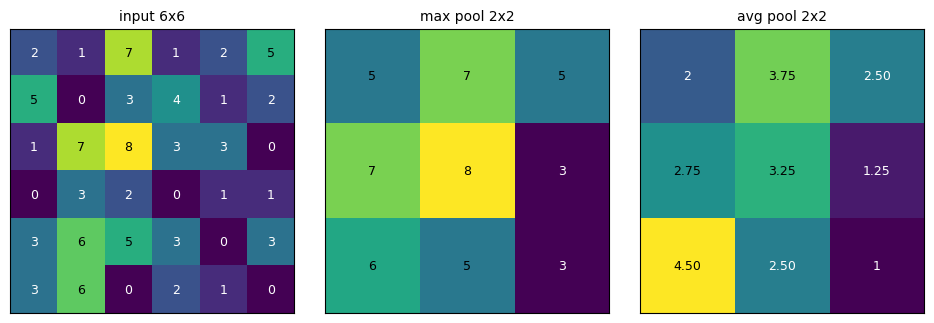

In [2]:
def pool2d(x, k=2, s=2, mode="max"):
    H, W = x.shape
    out_h = (H - k)//s + 1
    out_w = (W - k)//s + 1
    out = np.zeros((out_h, out_w))
    argmax_pos = {}                      # remember WHERE each max came from (for unpooling later)
    for i in range(out_h):
        for j in range(out_w):
            r, c = i*s, j*s
            window = x[r:r+k, c:c+k]
            if mode == "max":
                out[i, j] = window.max()
                # store the absolute (row,col) of the max inside the original map
                dr, dc = np.unravel_index(np.argmax(window), window.shape)
                argmax_pos[(i, j)] = (r+dr, c+dc)
            else:
                out[i, j] = window.mean()
    return out, argmax_pos

# the slide's 6x6 grid
grid = np.array([
    [2,1,7,1,2,5],
    [5,0,3,4,1,2],
    [1,7,8,3,3,0],
    [0,3,2,0,1,1],
    [3,6,5,3,0,3],
    [3,6,0,2,1,0],
], dtype=float)

mx, pos = pool2d(grid, 2, 2, "max")
av, _   = pool2d(grid, 2, 2, "avg")
print("max pooling:\n", mx)
print("\navg pooling:\n", av)

# cross-check the single-block example from the notes
block = np.array([[2,1],[5,0]], float)
print("\nnotes block -> max =", block.max(), " avg =", block.mean())
show_maps([grid, mx, av], ["input 6x6", "max pool 2x2", "avg pool 2x2"])

**What to notice.** Max pooling keeps the strongest activation in each block
(*did this feature fire anywhere?*); average pooling smooths. Either way three of
the four numbers in every 2×2 block are gone — that is the information loss the
decoder must later undo. We *saved the argmax positions* (`pos`) precisely so a
later max-unpooling layer can put values back where they came from.

## 3. Downsampling — strided convolution

The *learnable* alternative to pooling. A convolution that hops by `stride > 1`
produces a smaller output. We reproduce the notes' 5×5 input with the underlaid
3×3 kernel weights `{0,1,2}` and `stride=1` (valid padding) → 3×3 output, then show
that `stride=2` shrinks it further.

stride 1 (3x3 output):
 [[12. 12. 17.]
 [10. 17. 19.]
 [ 9.  6. 14.]]

stride 2 (2x2 output, downsampled):
 [[12. 17.]
 [ 9. 14.]]


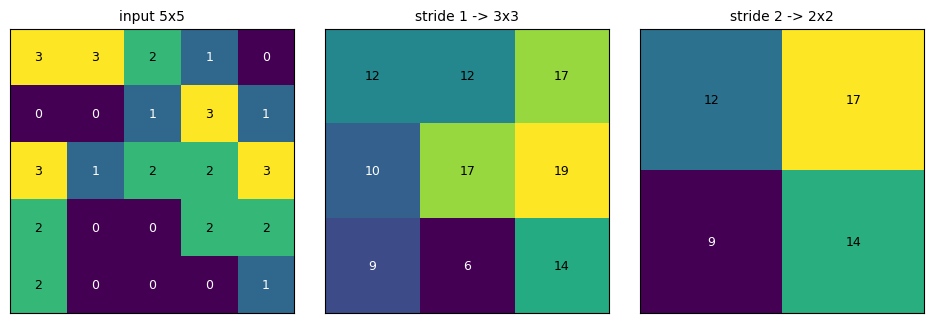

In [3]:
def conv2d(x, w, stride=1, pad=0):
    if pad: x = np.pad(x, pad)
    kh, kw = w.shape
    H, W = x.shape
    out_h = (H - kh)//stride + 1
    out_w = (W - kw)//stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            r, c = i*stride, j*stride
            out[i, j] = np.sum(x[r:r+kh, c:c+kw] * w)
    return out

x5 = np.array([
    [3,3,2,1,0],
    [0,0,1,3,1],
    [3,1,2,2,3],
    [2,0,0,2,2],
    [2,0,0,0,1],
], float)
kernel = np.array([[0,1,2],
                   [2,2,0],
                   [0,1,2]], float)

print("stride 1 (3x3 output):\n", conv2d(x5, kernel, stride=1))
print("\nstride 2 (2x2 output, downsampled):\n", conv2d(x5, kernel, stride=2))
show_maps([x5, conv2d(x5, kernel, 1), conv2d(x5, kernel, 2)],
          ["input 5x5", "stride 1 -> 3x3", "stride 2 -> 2x2"])

**Cost intuition (from the notes).** One conv layer costs about
`H·W·D_in·D_out·kh·kw` multiply–adds. Halving `H` and `W` (what a stride-2 layer or a
pool does) divides the spatial term by 4 — which is why segmentation networks
downsample *inside* the network before running the deep, expensive convolutions.

In [4]:
def conv_cost(H, W, Din, Dout, k=3):
    return H*W*Din*Dout*k*k

full = conv_cost(512, 512, 64, 64)
half = conv_cost(256, 256, 64, 64)
print(f"one 3x3 conv at 512x512, 64->64 ch : {full:,} MACs  (~{full/1e9:.1f} GMACs)")
print(f"same layer at 256x256             : {half:,} MACs  (~{half/1e9:.1f} GMACs)")
print(f"speedup from halving resolution    : {full/half:.0f}x")

one 3x3 conv at 512x512, 64->64 ch : 9,663,676,416 MACs  (~9.7 GMACs)
same layer at 256x256             : 2,415,919,104 MACs  (~2.4 GMACs)
speedup from halving resolution    : 4x


## 4. Upsampling — unpooling (fixed rules)

Three fixed (non-learnable) ways to grow a 2×2 map to 4×4:

- **Nearest neighbour** — copy each value into its whole 2×2 cell.
- **Bed of nails** — put each value in one fixed corner, zeros elsewhere.
- **Max unpooling** — put each value back at the *exact argmax position* recorded by
  the paired max-pool layer.

We reproduce all three on $\begin{bmatrix}1&2\\3&4\end{bmatrix}$, then do the full
pool→unpool round trip from the notes' 4×4 example to show detail being recovered.

nearest neighbour:
 [[1. 1. 2. 2.]
 [1. 1. 2. 2.]
 [3. 3. 4. 4.]
 [3. 3. 4. 4.]]

bed of nails:
 [[1. 0. 2. 0.]
 [0. 0. 0. 0.]
 [3. 0. 4. 0.]
 [0. 0. 0. 0.]]


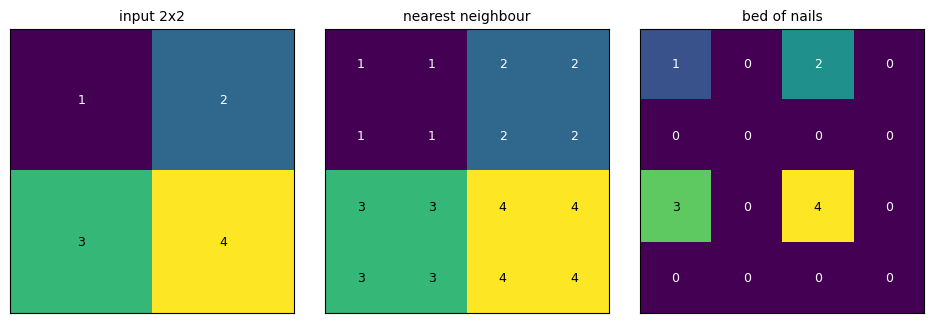

In [5]:
def nearest_unpool(x, k=2):
    return np.kron(x, np.ones((k, k)))           # Kronecker product = replicate blocks

def bed_of_nails(x, k=2):
    H, W = x.shape
    out = np.zeros((H*k, W*k))
    out[::k, ::k] = x                            # top-left of each cell
    return out

def max_unpool(x, argmax_pos, out_shape):
    out = np.zeros(out_shape)
    for (i, j), (r, c) in argmax_pos.items():
        out[r, c] = x[i, j]
    return out

small = np.array([[1,2],[3,4]], float)
print("nearest neighbour:\n", nearest_unpool(small))
print("\nbed of nails:\n", bed_of_nails(small))
show_maps([small, nearest_unpool(small), bed_of_nails(small)],
          ["input 2x2", "nearest neighbour", "bed of nails"])

max pooled 2x2:
 [[5. 6.]
 [7. 8.]]
stored argmax positions (out_idx -> orig row,col):
   (0, 0) -> (np.int64(1), np.int64(1))
   (0, 1) -> (np.int64(0), np.int64(2))
   (1, 0) -> (np.int64(3), np.int64(0))
   (1, 1) -> (np.int64(3), np.int64(3))

max-unpooled (values land back at original argmax slots):
 [[0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [3. 0. 0. 4.]]


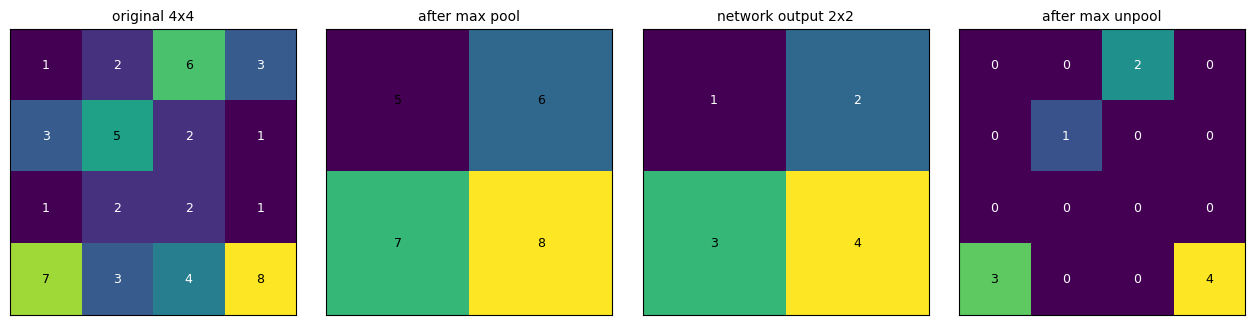

In [6]:
# Full round trip: the notes' 4x4 map -> max pool -> (network) -> max unpool
m4 = np.array([
    [1,2,6,3],
    [3,5,2,1],
    [1,2,2,1],
    [7,3,4,8],
], float)
pooled, positions = pool2d(m4, 2, 2, "max")
print("max pooled 2x2:\n", pooled)
print("stored argmax positions (out_idx -> orig row,col):")
for k, v in positions.items(): print("  ", k, "->", v)

# pretend the rest of the network returned this 2x2
returned = np.array([[1,2],[3,4]], float)
unpooled = max_unpool(returned, positions, m4.shape)
print("\nmax-unpooled (values land back at original argmax slots):\n", unpooled)
show_maps([m4, pooled, returned, unpooled],
          ["original 4x4", "after max pool", "network output 2x2", "after max unpool"])

**Why max unpooling matters.** Max pooling discarded *where* each maximum was;
storing that location lets us drop values back exactly there — restoring spatial
precision at boundaries. This is the same "don't lose the location" idea that
motivates RoI **Align** over RoI **pooling** (Section 9), and that skip connections
generalise to whole feature maps (Section 6).

## 5. Upsampling — transposed convolution (learnable)

> *For each input pixel value, multiply the whole filter by it and paste the scaled
> filter into the output at the pixel's position; sum where pastes overlap.*

This is the **learnable** upsampler. Start with the 1-D example from the notes:
input `[2, 3]`, filter `[1, 2, 1]`, stride 1 →

- pixel 2 → `[2,4,2]` at offset 0
- pixel 3 → `[3,6,3]` at offset 1
- overlap-add → `[2, 7, 8, 3]`

In [7]:
def transposed_conv1d(x, w, stride=1):
    n = len(x); k = len(w)
    out_len = (n - 1)*stride + k
    out = np.zeros(out_len)
    for i, v in enumerate(x):
        out[i*stride : i*stride + k] += v * w   # paste scaled filter, ACCUMULATE
    return out

print("input [2,3], filter [1,2,1]:")
print("  ->", transposed_conv1d(np.array([2,3]), np.array([1,2,1])))   # expect [2,7,8,3]

input [2,3], filter [1,2,1]:
  -> [2. 7. 8. 3.]


2x2 input upsampled to (5, 5) via transposed conv (stride 2):
 [[ 2.  4.  5.  6.  3.]
 [ 0.  2.  0.  3.  0.]
 [ 3.  6. 10. 14.  7.]
 [ 0.  1.  0.  4.  0.]
 [ 1.  2.  5.  8.  4.]]


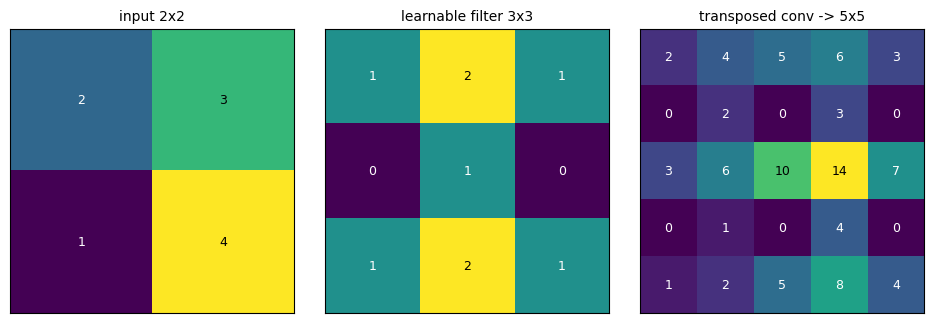

In [8]:
def transposed_conv2d(x, w, stride=1):
    H, W = x.shape; kh, kw = w.shape
    out_h = (H-1)*stride + kh
    out_w = (W-1)*stride + kw
    out = np.zeros((out_h, out_w))
    for i in range(H):
        for j in range(W):
            r, c = i*stride, j*stride
            out[r:r+kh, c:c+kw] += x[i, j] * w   # one scaled-filter "output map" per pixel, summed
    return out

# 2x2 feature map upsampled by a 3x3 filter, stride 2 -> 5x5
feat = np.array([[2,3],
                 [1,4]], float)
filt = np.array([[1,2,1],
                 [0,1,0],
                 [1,2,1]], float)
up = transposed_conv2d(feat, filt, stride=2)
print("2x2 input upsampled to", up.shape, "via transposed conv (stride 2):\n", up)
show_maps([feat, filt, up], ["input 2x2", "learnable filter 3x3", "transposed conv -> 5x5"])

**The key point.** Because the filter weights are *learned*, the network learns
*how* to upsample rather than being stuck with a fixed rule — the notes' "values are
different! transpose convolution kernels are learnable." Pooling/unpooling have no
parameters; transposed convolution does.

## 6. A mini encoder–decoder (U-Net forward pass)

Now we chain the pieces into the **downsample → bottleneck → upsample** shape, with a
**skip connection** that concatenates the encoder feature onto the decoder feature —
U-Net's "copy and crop". We track the *shapes* the way the notes track
`572→284→…→32→…→392`, on a small toy size so it runs instantly.

To keep it pure-NumPy and readable we use single-channel maps and a fixed (random)
filter per stage; the goal is the **data flow and shapes**, not training.

stage                       shape
----------------------------------------
enc1 conv (same)            (8, 8)
pool1 (down /2)             (4, 4)
enc2 conv (same)            (4, 4)
pool2 (down /2)             (2, 2)
bottleneck conv (same)      (2, 2)
up2 (transposed /×2)        (4, 4)
skip-concat with enc2       (4, 4)
dec2 conv (same)            (4, 4)
up1 (transposed /×2)        (8, 8)
skip-concat with enc1       (8, 8)
dec1 conv (same)            (8, 8)


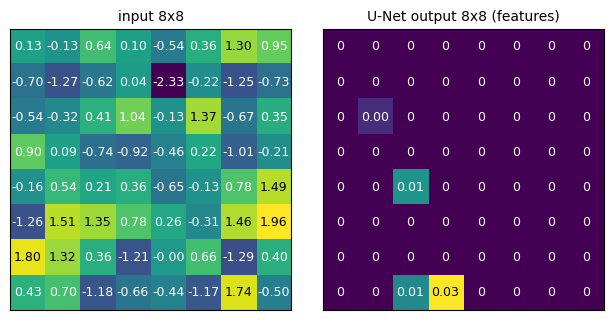

In [9]:
rng = np.random.default_rng(0)

def relu(x): return np.maximum(0, x)

def conv_same(x, w):
    "3x3 conv with zero-pad 1 so H,W are preserved (the 'conv 3x3, ReLU' blocks)."
    return relu(conv2d(x, w, stride=1, pad=1))

class MiniUNet:
    # Toy 1-channel U-Net: 2 down steps, bottleneck, 2 up steps, skip-concat (summed for 1 ch)
    def __init__(self, seed=0):
        r = np.random.default_rng(seed)
        self.w_enc1 = r.normal(0,.3,(3,3))
        self.w_enc2 = r.normal(0,.3,(3,3))
        self.w_bott = r.normal(0,.3,(3,3))
        self.w_dec2 = r.normal(0,.3,(3,3))
        self.w_dec1 = r.normal(0,.3,(3,3))
        self.up = np.array([[1,1],[1,1]], float)   # simple 2x2 upsample filter

    def forward(self, x, verbose=True):
        log = []
        def note(name, a): log.append((name, a.shape)); return a
        e1 = note("enc1 conv (same)",        conv_same(x, self.w_enc1))
        p1, _ = pool2d(e1, 2, 2, "max");      note("pool1 (down /2)", p1)
        e2 = note("enc2 conv (same)",        conv_same(p1, self.w_enc2))
        p2, _ = pool2d(e2, 2, 2, "max");      note("pool2 (down /2)", p2)
        b  = note("bottleneck conv (same)",  conv_same(p2, self.w_bott))
        u2 = transposed_conv2d(b, self.up, stride=2); note("up2 (transposed /×2)", u2)
        u2 = u2[:e2.shape[0], :e2.shape[1]]                       # crop to match skip
        c2 = note("skip-concat with enc2", u2 + e2)               # (concat→sum for 1 channel)
        d2 = note("dec2 conv (same)",        conv_same(c2, self.w_dec2))
        u1 = transposed_conv2d(d2, self.up, stride=2); note("up1 (transposed /×2)", u1)
        u1 = u1[:e1.shape[0], :e1.shape[1]]
        c1 = note("skip-concat with enc1", u1 + e1)
        d1 = note("dec1 conv (same)",        conv_same(c1, self.w_dec1))
        if verbose:
            print(f"{'stage':<28}{'shape'}")
            print("-"*40)
            for name, sh in log: print(f"{name:<28}{sh}")
        return d1

net = MiniUNet(seed=1)
img = rng.normal(0, 1, (8, 8))     # toy 8x8 'image'
out = net.forward(img)
show_maps([img, out], ["input 8x8", "U-Net output 8x8 (features)"])

Notice the resolution goes **8 → 4 → 2 (bottleneck) → 4 → 8**: lost on the way
down (cheap deep convs), rebuilt on the way up, with skip connections handing the
high-resolution detail straight across. That mirrors the real U-Net's
`572→…→32→…→388`, just smaller.

## 7. The dense-prediction head: scores → softmax → label map

The decoder ends in a `1×1` conv that produces a **score tensor** of shape
`C × H × W` — a `C`-vector of class scores per pixel. A per-pixel **softmax** turns
those into probabilities, and a per-pixel **argmax** collapses them to the final
`H × W` **label map**. This is the segmentation analogue of image classification,
done 10,000 times (once per pixel) instead of once.

per-pixel probabilities sum to 1?  True

label map (each cell = winning class index):
 [[1 0 0 0 2]
 [2 1 2 0 0]
 [0 1 1 0 0]
 [0 0 2 1 2]
 [1 2 2 0 1]]


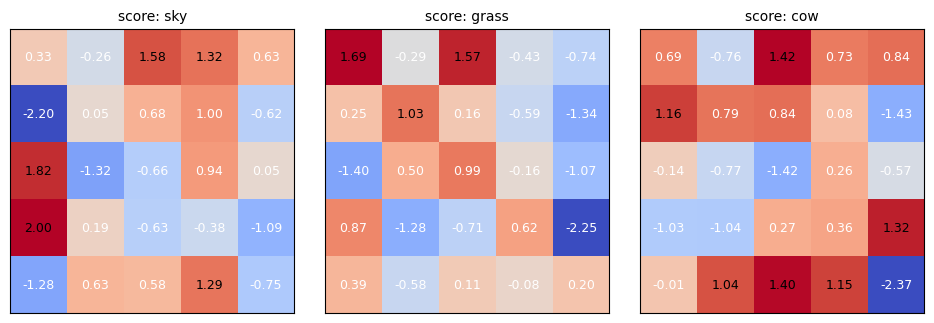

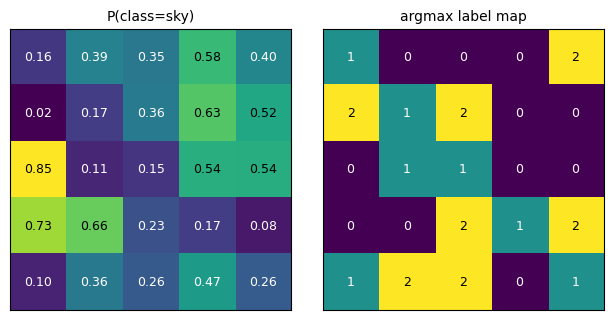


C*H*W score tensor size: 75  -> collapses to H*W = 25 labels


In [10]:
def softmax_chw(scores):
    "scores: (C,H,W) -> per-pixel softmax over C."
    s = scores - scores.max(axis=0, keepdims=True)   # numerical stability
    e = np.exp(s)
    return e / e.sum(axis=0, keepdims=True)

C, H, W = 3, 5, 5     # 3 classes (e.g. sky, grass, cow), tiny 5x5 image
scores = rng.normal(0, 1, (C, H, W))
probs  = softmax_chw(scores)
labels = probs.argmax(axis=0)        # the H x W label map

print("per-pixel probabilities sum to 1? ", np.allclose(probs.sum(0), 1))
print("\nlabel map (each cell = winning class index):\n", labels)

class_names = ["sky", "grass", "cow"]
show_maps([scores[0], scores[1], scores[2]],
          [f"score: {n}" for n in class_names], cmap="coolwarm")
show_maps([probs[0], labels],
          ["P(class=sky)", "argmax label map"], cmap="viridis")
print("\nC*H*W score tensor size:", C*H*W, " -> collapses to H*W =", H*W, "labels")

## 8. Semantic vs. instance segmentation — the difference, in code

Semantic segmentation gives the **class** of each pixel; two overlapping cows both
become `cow` with **no boundary** between them. Instance segmentation additionally
tags **which object** each pixel belongs to. Below: the same scene, two outputs.

instance map (0=bg, 1=cow#1, 2=cow#2): distinct objects kept separate
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 1 0 0 0 0]
 [0 1 1 1 1 1 0 0 0 0]
 [0 1 1 1 2 2 2 2 2 0]
 [0 1 1 1 2 2 2 2 2 0]
 [0 1 1 1 2 2 2 2 2 0]
 [0 0 0 0 2 2 2 2 2 0]
 [0 0 0 0 2 2 2 2 2 0]
 [0 0 0 0 0 0 0 0 0 0]]

semantic map (0=bg, 1=cow): the two cows merge into one blob
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 1 0 0 0 0]
 [0 1 1 1 1 1 0 0 0 0]
 [0 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 0]
 [0 0 0 0 1 1 1 1 1 0]
 [0 0 0 0 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 0]]


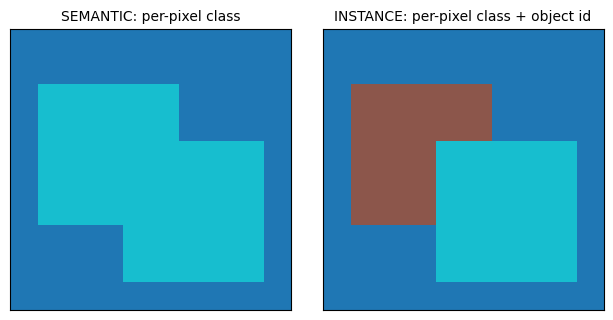


semantic: 44 pixels labelled 'cow', 0 boundaries between cows
instance: same 44 pixels, split into 2 objects


In [11]:
# A 10x10 toy scene: background=0, two overlapping 'cow' blobs
scene_instance = np.zeros((10, 10), int)
scene_instance[2:7, 1:6] = 1     # cow #1
scene_instance[4:9, 4:9] = 2     # cow #2 (overlaps cow #1 in the middle)

# SEMANTIC view: every cow pixel is just 'cow' (class 1); instances merged
scene_semantic = (scene_instance > 0).astype(int)

print("instance map (0=bg, 1=cow#1, 2=cow#2): distinct objects kept separate")
print(scene_instance)
print("\nsemantic map (0=bg, 1=cow): the two cows merge into one blob")
print(scene_semantic)

show_maps([scene_semantic, scene_instance],
          ["SEMANTIC: per-pixel class", "INSTANCE: per-pixel class + object id"],
          cmap="tab10")
n_cow_pixels = (scene_instance>0).sum()
print(f"\nsemantic: {n_cow_pixels} pixels labelled 'cow', 0 boundaries between cows")
print(f"instance: same {n_cow_pixels} pixels, split into {scene_instance.max()} objects")

## 9. Instance-detection layers

The layers that turn a detector into an *instance* segmenter (Mask R-CNN, prev.
chapter). We reproduce the exact numeric examples from the notes.

### 9a. Intersection over Union (IoU / Jaccard)
Notes example: a 10×10 ground-truth box and a 10×10 prediction overlapping in a 6×8
rectangle → IoU = 48 / 152 ≈ 0.316.

In [12]:
def iou(boxA, boxB):
    "boxes as (x1,y1,x2,y2). Returns intersection-over-union."
    ax1,ay1,ax2,ay2 = boxA; bx1,by1,bx2,by2 = boxB
    ix1,iy1 = max(ax1,bx1), max(ay1,by1)
    ix2,iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)
    inter = iw*ih
    areaA = (ax2-ax1)*(ay2-ay1)
    areaB = (bx2-bx1)*(by2-by1)
    union = areaA + areaB - inter
    return inter/union, inter, union

# ground truth 10x10 at origin; prediction 10x10 shifted to overlap in 6x8
G = (0,0,10,10)
P = (4,2,14,12)          # overlap region is x in [4,10] (=6), y in [2,10] (=8) -> 6x8
val, inter, union = iou(P, G)
print(f"intersection area = {inter}  (expect 48)")
print(f"union area        = {union}  (expect 152)")
print(f"IoU               = {val:.3f}  (expect ~0.316)")
print("=> below the usual 0.5 threshold -> NOT a correct detection")

intersection area = 48  (expect 48)
union area        = 152  (expect 152)
IoU               = 0.316  (expect ~0.316)
=> below the usual 0.5 threshold -> NOT a correct detection


### 9b. Non-Maximum Suppression (NMS)
Notes example: one face fires three overlapping boxes with scores 0.95, 0.80, 0.62 →
NMS keeps the 0.95 box and suppresses the rest.

In [13]:
def nms(boxes, scores, iou_thresh=0.5):
    idxs = list(np.argsort(scores)[::-1])    # high score first
    keep = []
    while idxs:
        cur = idxs.pop(0)
        keep.append(cur)
        idxs = [i for i in idxs if iou(boxes[cur], boxes[i])[0] < iou_thresh]
    return keep

boxes = [(10,10,60,60),(12,11,62,63),(9,13,58,59)]   # 3 heavily-overlapping boxes
scores = [0.95, 0.80, 0.62]
kept = nms(boxes, scores, 0.5)
print("kept box indices:", kept, " -> scores kept:", [scores[i] for i in kept])
print("one object -> one final box (the 0.95 one); the other two suppressed")

kept box indices: [np.int64(0)]  -> scores kept: [0.95]
one object -> one final box (the 0.95 one); the other two suppressed


### 9c. RoI pooling — the **two quantizations**
Notes example: VGG16 downsamples by 32; an 800×800 image → feature map 800/32 = 25
(clean), but a 665-px box → 665/32 = 20.78 which gets **rounded to 20** (first
quantization), and splitting 20 into a 7×7 grid gives 20/7 = 2.86 cells, **rounded
again** (second quantization). Each rounding can misalign by up to ~32 px on the
original image.

image -> feature map : 800/32 = 25.0  (integer, clean)
box   -> feature map : 665/32 = 20.78  -> ROUND to 20 (quant #1)
split 20 into 7x7 grid : 20/7 = 2.86 cells wide -> ROUND each boundary (quant #2)
misalignment per rounding  : up to ~32 px on the original image

RoI-pooled output shape: (7, 7)


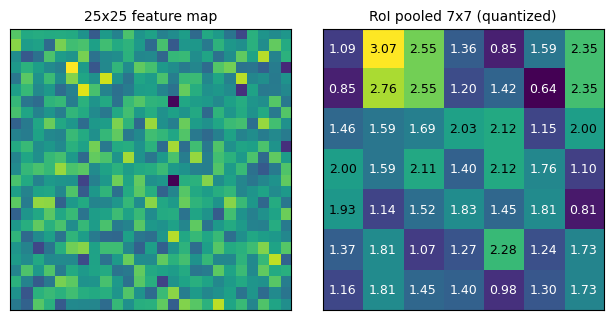

In [14]:
stride = 32
img_size = 800
box_size = 665
print(f"image -> feature map : {img_size}/{stride} = {img_size/stride}  (integer, clean)")
roi_fp = box_size/stride
print(f"box   -> feature map : {box_size}/{stride} = {roi_fp:.2f}  -> ROUND to {round(roi_fp-0.5)} (quant #1)")
roi_q = int(roi_fp)                       # 20
cell = roi_q/7
print(f"split {roi_q} into 7x7 grid : {roi_q}/7 = {cell:.2f} cells wide -> ROUND each boundary (quant #2)")
print(f"misalignment per rounding  : up to ~{stride} px on the original image")

def roi_pool(feat, roi_fp_box, out=(7,7)):
    "Quantize the RoI to integers then max-pool a fixed grid (the two roundings)."
    x1,y1,x2,y2 = [int(round(v)) for v in roi_fp_box]    # QUANT #1
    region = feat[y1:y2, x1:x2]
    rh, rw = region.shape
    oh, ow = out
    pooled = np.zeros(out)
    for i in range(oh):
        for j in range(ow):
            r0 = int(np.floor(i*rh/oh)); r1 = int(np.ceil((i+1)*rh/oh))   # QUANT #2
            c0 = int(np.floor(j*rw/ow)); c1 = int(np.ceil((j+1)*rw/ow))
            cell_vals = region[r0:max(r1,r0+1), c0:max(c1,c0+1)]
            pooled[i,j] = cell_vals.max() if cell_vals.size else 0
    return pooled

feat_map = rng.normal(0,1,(25,25))
pooled = roi_pool(feat_map, (2.3, 1.7, 23.08, 22.4))   # fractional box gets rounded
print("\nRoI-pooled output shape:", pooled.shape)
show_maps([feat_map, pooled], ["25x25 feature map", "RoI pooled 7x7 (quantized)"])

### 9d. RoI Align — **no quantization** (bilinear interpolation)
Notes example: sample point (9.94, 6.50) in the unit cell with corners
`Q11=0.1, Q21=0.2, Q12=0.7, Q22=0.3`. Because the point sits exactly on `y=6.5=y1`,
the y-weight kills the bottom row and the result is the horizontal interpolation of
the top edge: **0.144**.

In [15]:
def bilinear(feat, x, y):
    "Sample feat at fractional (x,y) by bilinear interpolation of its 4 integer-grid neighbours."
    x1, y1 = int(np.floor(x)), int(np.floor(y))
    x2, y2 = x1+1, y1+1
    Q11 = feat[y1, x1]; Q21 = feat[y1, x2]
    Q12 = feat[y2, x1]; Q22 = feat[y2, x2]
    wx2, wx1 = x2-x, x-x1
    wy2, wy1 = y2-y, y-y1
    return (wy2*(wx2*Q11 + wx1*Q21) + wy1*(wx2*Q12 + wx1*Q22))

# A general-purpose bilinear sampler on an integer grid (used by RoI Align below).
demo = np.array([[0.1, 0.2],
                 [0.7, 0.3]], float)   # corners Q11,Q21 / Q12,Q22 at integer coords (0,0),(1,0),(0,1),(1,1)
print("sample at (0.44, 0.0) of the 2x2 corner grid =", round(bilinear(demo, 0.44, 0.0), 3))

# Reproduce the NOTES example precisely. The notes put the sample point (9.94, 6.50)
# in a unit cell whose corners are x1=9.5, x2=10.5 and y1=6.5, y2=7.5, with
# Q11=0.1, Q21=0.2, Q12=0.7, Q22=0.3. We compute that interpolation directly:
x, y = 9.94, 6.50
x1, x2, y1, y2 = 9.5, 10.5, 6.5, 7.5
Q11, Q21, Q12, Q22 = 0.1, 0.2, 0.7, 0.3
wx1, wx2 = (x-x1)/(x2-x1), (x2-x)/(x2-x1)     # 0.44, 0.56
wy1, wy2 = (y-y1)/(y2-y1), (y2-y)/(y2-y1)     # 0.00, 1.00
P = wy2*(wx2*Q11 + wx1*Q21) + wy1*(wx2*Q12 + wx1*Q22)
print(f"\nnotes example, point ({x}, {y}) in cell [{x1},{x2}]x[{y1},{y2}]:")
print(f"  x-weights = ({wx2:.2f}, {wx1:.2f}),  y-weights = ({wy2:.2f}, {wy1:.2f})")
print(f"  P = {P:.3f}   (notes expect 0.144)")
print("  y=6.50 sits exactly on y1 -> y-weight kills the bottom row,")
print(f"  so P reduces to the top edge: 0.56*0.1 + 0.44*0.2 = {0.56*0.1 + 0.44*0.2:.3f}")

sample at (0.44, 0.0) of the 2x2 corner grid = 0.144

notes example, point (9.94, 6.5) in cell [9.5,10.5]x[6.5,7.5]:
  x-weights = (0.56, 0.44),  y-weights = (1.00, 0.00)
  P = 0.144   (notes expect 0.144)
  y=6.50 sits exactly on y1 -> y-weight kills the bottom row,
  so P reduces to the top edge: 0.56*0.1 + 0.44*0.2 = 0.144


RoI-Align output shape: (7, 7) (fractional box, no rounding)


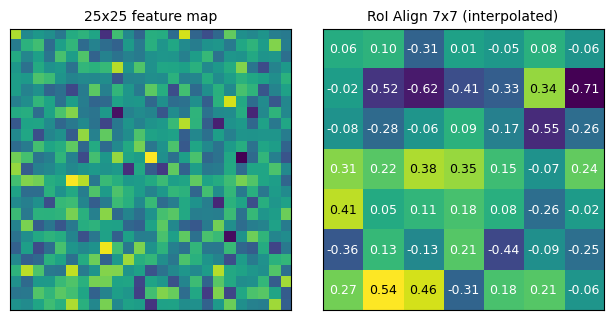

In [16]:
def roi_align(feat, box, out=(2,2), samples=2):
    "No rounding: keep box as floats, sample `samples`^2 bilinear points per cell, avg-pool."
    x1,y1,x2,y2 = box                       # all floats, NO quantization
    rw, rh = (x2-x1), (y2-y1)
    oh, ow = out
    res = np.zeros(out)
    for i in range(oh):
        for j in range(ow):
            cy0 = y1 + rh*i/oh; cx0 = x1 + rw*j/ow
            ch, cw = rh/oh, rw/ow
            pts = []
            for si in range(samples):
                for sj in range(samples):
                    py = cy0 + ch*(si+0.5)/samples
                    px = cx0 + cw*(sj+0.5)/samples
                    pts.append(bilinear(feat, px, py))
            res[i,j] = np.mean(pts)          # avg-pool the sampled points
    return res

feat_map = rng.normal(0,1,(25,25))
aligned = roi_align(feat_map, (2.3, 1.7, 23.08, 22.4), out=(7,7), samples=2)
print("RoI-Align output shape:", aligned.shape, "(fractional box, no rounding)")
show_maps([feat_map, aligned], ["25x25 feature map", "RoI Align 7x7 (interpolated)"])

**Why RoI Align matters.** RoI pooling's two roundings shift features by up to
~32 px — invisible to a box classifier but **fatal to a pixel-accurate mask**. RoI
Align keeps the box coordinates as floats and reads the feature map by bilinear
interpolation, so the mask head sees a *precisely aligned* feature. This single
change is what makes high-quality instance masks possible.

## Summary — the throughline

| layer | role | learnable? | key idea |
|---|---|---|---|
| max / avg pool | downsample | no | shrink, lose detail (save argmax!) |
| strided conv | downsample | yes | shrink with learned weights |
| nearest / bed-of-nails | upsample | no | fixed spread rule |
| max unpool | upsample | no | restore detail via stored argmax |
| transposed conv | upsample | **yes** | scale filter per pixel, overlap-add |
| skip connection | fuse | no | hand fine detail across the U |
| softmax + argmax | head | no | C×H×W scores → H×W labels |
| IoU / NMS | detection | no | match & deduplicate boxes |
| RoI pool | crop features | no | fixed size, **2 roundings** |
| RoI Align | crop features | no | **no rounding**, bilinear |

Every architectural step removes the bottleneck left by the previous one:
sliding-window redundancy → fully convolutional; full-resolution cost →
downsample/upsample; lost spatial detail → unpooling, skips, and RoI Align.